# Cars 4 You Machine Learning Project


[GitHub](https://github.com/lcarvas/mlproj-masters)


## Group 54 Members


- Diogo Carvalho - 20221935
- Luiza Salum - 20221902
- Ricardo Pereira - 20250343


### Contributions


Regarding individual contributions, it’s honestly very hard to isolate who did
what in a strict way. At the start, each of us explored the dataset separately
and from that point on, we all contributed to ideas, analysis, and writing
different parts of this "report". We had weekly meetings, talked almost daily,
and worked together in all projects of this semester. It doesn’t make sense for
any of us to claim that one person did “more” or “less". We can afirm that Diogo
was more comfortable exploring "advanced" techniques, while Ricardo and Luiza
had less experience with machine learning, so they compensated in other areas
(especially by taking on more work in the other projects), which allowed Diogo
the time and space to go deeper into this one. In the end, it all balanced out
and we believed we did good projects as a group.

So the fairest assessment is simply: 33% contribution from each member.


## Abstract


Cars 4 You, an online car‑resale platform, aims to reduce long waiting times
caused by mandatory mechanic inspections. To address this challenge, we
developed a predictive system capable of estimating car prices directly from
user‑submitted information. Using the company’s 2020 historical dataset, we
implemented a complete pipeline covering preprocessing, correction of
inconsistent values, categorical cleaning, feature selection, normalization, and
model training. Five regression models were optimized and benchmarked through
5‑fold cross‑validation and hyperparameter tuning, then evaluated on an
independent test set to validate generalization. Based on this process, Random
Forest emerged as the best model for predicting car prices based on the given
dataset. It showed the highest R² score and the lowest values across all error
metrics we used for evaluation (MAE, MSE and RMSE).


## Identifying Business Needs


Our client, Cars 4 You, is an online car resale platform whose business model
relies on users submitting details about their vehicles before sending them to a
mechanic for inspection and pricing. As the business grew, long waiting times
emerged. Cars 4 You requested our team to help them reduce these waiting times
that are currently driving potential sellers to competitors.

To solve this, they want a model capable of predicting car prices using only the
information users submit online, removing the need for an initial mechanic
evaluation.

Using their 2020 dataset, our work focuses on three goals:

1. Creating and comparing regression models for price prediction;
2. Improving the best model through feature selection and hyperparameter tuning;
3. Extracting insights that help Cars 4 You understand what drives price
   variation.

To ensure reliable comparison between models, we use 5‑fold cross‑validation as
our main evaluation method, paired with hyperparameter tuning for all estimators
(well, except linear regression).


## Configurations and Imports


In [14]:
from __future__ import annotations

import warnings
from typing import TYPE_CHECKING, cast

import numpy as np
import optuna
import polars as pl
from optuna.integration import OptunaSearchCV
from sklearn import clone
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import ElasticNet, LinearRegression
from sklearn.model_selection import cross_validate
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import FunctionTransformer, Pipeline
from sklearn.tree import DecisionTreeRegressor

%load_ext autoreload
%autoreload 2

from funcs.data_import import describe_data, import_data
from funcs.pipeline import (
    build_feature_selection_pipeline,
    build_permutation_feature_selection_pipeline,
    build_preprocessing_pipeline,
)

if TYPE_CHECKING:
    from collections.abc import Mapping, Sequence
    from typing import Any

    from numpy.typing import NDArray
    from pandas import DataFrame, Series

warnings.filterwarnings("ignore")

pl.Config.set_tbl_cols(-1)
pl.Config.set_tbl_rows(20)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


polars.config.Config

### Importing Data


In [15]:
train_df: pl.DataFrame = import_data("data/train.csv")
test_df: pl.DataFrame = import_data("data/test.csv")

## Exploration


statistic,carID,Brand,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize,paintQuality%,previousOwners,hasDamage
str,f64,str,str,f64,f64,str,f64,str,f64,f64,f64,f64,f64,f64
"""count""",75973.0,"""74452""","""74456""",74482.0,75973.0,"""74451""",74510.0,"""74462""",68069.0,68047.0,74457.0,74449.0,74423.0,74425.0
"""null_count""",0.0,"""1521""","""1517""",1491.0,0.0,"""1522""",1463.0,"""1511""",7904.0,7926.0,1516.0,1524.0,1550.0,1548.0
"""mean""",37986.0,null,null,2017.096611,16881.889553,null,23004.184088,null,120.329078,55.152666,1.660136,64.590667,1.99458,0.0
"""std""",21931.660338,null,null,2.208704,9736.926322,null,22129.788366,null,65.521176,16.497837,0.573462,21.021065,1.472981,0.0
"""min""",0.0,"""AUD""",""" 1 SERIE""",1970.0,450.0,""" MANUAL """,-58540.574478,"""DIESE""",-91.12163,-43.421768,-0.103493,1.638913,-2.34565,0.0
"""25%""",18993.0,null,null,2016.0,10200.0,null,7423.0,null,125.0,46.3,1.2,47.0,1.0,0.0
"""50%""",37986.0,null,null,2017.0,14699.0,null,17300.0,null,145.0,54.3,1.6,65.0,2.0,0.0
"""75%""",56979.0,null,null,2019.0,20950.0,null,32428.0,null,145.0,62.8,2.0,82.0,3.0,0.0
"""max""",75972.0,"""yundai""","""yaris""",2024.121759,159999.0,"""utomatic""",323000.0,"""ybrid""",580.0,470.8,6.6,125.594308,6.258371,0.0


Schema([('carID', Int64),
        ('Brand', String),
        ('model', String),
        ('year', Float64),
        ('price', Int64),
        ('transmission', String),
        ('mileage', Float64),
        ('fuelType', String),
        ('tax', Float64),
        ('mpg', Float64),
        ('engineSize', Float64),
        ('paintQuality%', Float64),
        ('previousOwners', Float64),
        ('hasDamage', Float64)])

'Duplicated rows: 0'

column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40,column_41,column_42,column_43,column_44,column_45,column_46,column_47,column_48,column_49,column_50,column_51,column_52,column_53,column_54,column_55,column_56,column_57,column_58,column_59,column_60,column_61,column_62,column_63,column_64,column_65,column_66,column_67,column_68,column_69,column_70,column_71,column_72
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""yunda""","""Skoda""","""MERCEDE""","""V""","""Toyota""","""Skod""","""Ope""","""Ford""","""mw""","""AUD""","""Opel""","""toyot""","""SKOD""","""ford""","""udi""","""OPEL""","""mercede""","""FOR""","""mercedes""","""ercedes""","""HYUNDAI""","""AUDI""","""KODA""","""PEL""","""skoda""","""ud""","""hyunda""","""toyota""","""pe""","""TOYOT""","""VW""","""SKODA""",null,"""FORD""","""kod""","""pel""","""koda""","""skod""","""Mercedes""","""Audi""","""Toyot""","""Aud""","""MERCEDES""","""for""","""Hyundai""","""ERCEDES""","""vw""","""MW""","""ercede""","""oyota""","""ope""","""HYUNDA""","""TOYOTA""","""BMW""","""BM""","""Hyunda""","""v""","""bmw""","""W""","""ord""","""opel""","""aud""","""w""","""audi""","""OPE""","""ORD""","""For""","""OYOTA""","""Mercede""","""UDI""","""or""","""hyundai""","""yundai"""
"""3""","""3973""","""4""","""197""","""4289""","""79""","""180""","""14808""","""4""","""2""","""8645""","""1""","""1""","""307""","""143""","""169""","""3""","""5""","""228""","""233""","""72""","""144""","""2""","""3""","""93""","""3""","""3""","""84""","""4""","""1""","""9780""","""72""","""1521""","""316""","""2""","""178""","""80""","""1""","""10754""","""6749""","""72""","""142""","""227""","""7""","""3066""","""3""","""193""","""145""","""7""","""91""","""4""","""2""","""82""","""6968""","""141""","""59""","""7""","""134""","""203""","""315""","""165""","""3""","""5""","""135""","""4""","""5""","""293""","""2""","""215""","""4""","""7""","""63""","""68"""


column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40,column_41,column_42,column_43,column_44,column_45,column_46,column_47,column_48,column_49,column_50,column_51,column_52,column_53,column_54,column_55,column_56,column_57,column_58,column_59,column_60,column_61,column_62,column_63,column_64,column_65,column_66,column_67,column_68,column_69,column_70,column_71,column_72,column_73,column_74,column_75,column_76,column_77,column_78,column_79,column_80,column_81,column_82,column_83,column_84,column_85,column_86,column_87,column_88,column_89,column_90,column_91,column_92,column_93,column_94,column_95,column_96,column_97,column_98,column_99,column_100,column_101,column_102,column_103,column_104,column_105,column_106,column_107,column_108,column_109,column_110,column_111,column_112,column_113,column_114,column_115,column_116,column_117,column_118,column_119,column_120,column_121,column_122,column_123,column_124,column_125,column_126,column_127,column_128,column_129,column_130,column_131,column_132,column_133,column_134,column_135,column_136,column_137,column_138,column_139,column_140,column_141,column_142,column_143,column_144,column_145,column_146,column_147,column_148,column_149,column_150,column_151,column_152,column_153,column_154,column_155,column_156,column_157,column_158,column_159,column_160,column_161,column_162,column_163,column_164,column_165,column_166,column_167,column_168,column_169,column_170,column_171,column_172,column_173,column_174,column_175,column_176,column_177,column_178,column_179,column_180,column_181,column_182,column_183,column_184,column_185,column_186,column_187,column_188,column_189,column_190,column_191,column_192,column_193,column_194,column_195,column_196,column_197,column_198,column_199,column_200,column_201,column_202,column_203,column_204,column_205,column_206,column_207,column_208,column_209,column_210,column_211,column_212,column_213,column_214,column_215,column_216,column_217,column_218,column_219,column_220,column_221,column_222,column_223,column_224,column_225,column_226,column_227,column_228,column_229,column_230,column_231,column_232,column_233,column_234,column_235,column_236,column_237,column_238,column_239,column_240,column_241,column_242,column_243,column_244,column_245,column_246,column_247,column_248,column_249,column_250,column_251,column_252,column_253,column_254,column_255,column_256,column_257,column_258,column_259,column_260,column_261,column_262,column_263,column_264,column_265,column_266,column_267,column_268,column_269,column_270,column_271,column_272,column_273,column_274,column_275,column_276,column_277,column_278,column_279,column_280,column_281,column_282,column_283,column_284,column_285,column_286,column_287,column_288,column_289,column_290,column_291,column_292,column_293,column_294,column_295,column_296,column_297,column_298,column_299,column_300,column_301,column_302,column_303,column_304,column_305,column_306,column_307,column_308,column_309,column_310,column_311,column_312,column_313,column_314,column_315,column_316,column_317,column_318,column_319,column_320,column_321,column_322,column_323,column_324,column_325,column_326,column_327,column_328,column_329,column_330,column_331,column_332,column_333,column_334,column_335,column_336,column_337,column_338,column_339,column_340,column_341,column_342,column_343,column_344,column_345,column_346,column_347,column_348,column_349,column_350,column_351,column_352,column_353,column_354,column_355,column_356,column_357,column_358,column_359,column_360,column_361,column_362,column_363,column_364,column_365,column_366,column_367,column_368,column_369,column_370,column_371,column_372,column_

column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40,column_41,column_42,column_43,column_44
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2009.0,2010.0,2024.121759,2023.389822,1997.0,2010.268635,2023.977311,1998.0,2014.0,2010.676968,2001.0,1996.0,2023.367078,2018.0,2023.116964,2016.0,2011.111188,2010.371546,2011.0,1999.0,2005.0,2017.0,2007.0,2010.746403,2023.267989,2022.878006,1970.0,2006.0,2013.0,2012.0,2023.605276,2004.0,2022.696685,2020.0,2009.816757,2010.565009,2019.0,2002.0,2011.210853,2003.0,null,2000.0,2008.0,2015.0,2012.69574
228.0,241.0,34.0,53.0,2.0,20.0,55.0,5.0,2930.0,82.0,15.0,1.0,26.0,10304.0,77.0,11502.0,15.0,35.0,318.0,5.0,64.0,16146.0,123.0,58.0,43.0,12.0,2.0,62.0,1902.0,478.0,39.0,35.0,19.0,3174.0,37.0,47.0,20271.0,25.0,50.0,29.0,1491.0,6.0,158.0,5733.0,21.0


column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34,column_35,column_36,column_37,column_38,column_39,column_40
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""manual ""","""MANUA""","""emi-Auto""",""" Manual ""","""nknow""",""" Manual""","""Other""","""MANUAL""","""SEMI-AUTO""","""automati""","""Automati""","""utomati""","""unknow""",null,"""UNKNOWN""","""Automatic""","""Manua""","""EMI-AUTO""","""AUTOMATIC""",""" MANUAL ""","""emi-auto""","""Semi-Aut""","""Manual""",""" manual ""","""nknown""","""unknown""","""anua""","""semi-auto""","""emi-Aut""","""AUTOMATI""","""SEMI-AUT""","""UTOMATIC""","""anual""","""manua""","""Semi-Auto""","""Manual ""","""manual""","""semi-aut""","""automatic""","""ANUAL""","""utomatic"""
"""1""","""11""","""325""","""366""","""1""","""7""","""5""","""801""","""309""","""6""","""304""","""6""","""18""","""1522""","""14""","""14003""","""759""","""7""","""289""","""9""","""10""","""332""","""38050""","""6""","""13""","""690""","""12""","""324""","""5""","""6""","""11""","""2""","""804""","""2""","""15545""","""16""","""770""","""4""","""282""","""13""","""313"""


column_0,column_1,column_2,column_3,column_4,column_5,column_6,column_7,column_8,column_9,column_10,column_11,column_12,column_13,column_14,column_15,column_16,column_17,column_18,column_19,column_20,column_21,column_22,column_23,column_24,column_25,column_26,column_27,column_28,column_29,column_30,column_31,column_32,column_33,column_34
str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str,str
"""iesel""","""Diese""","""Hybrid""","""other""","""Diesel""","""DIESE""","""Other""","""HYBRID""","""Petro""","""iese""","""Othe""","""DIESEL""","""PETRO""","""ybrid""","""IESEL""","""Petrol""","""etrol""","""Hybri""","""petrol""","""petro""","""YBRID""","""etro""","""OTHER""","""Electric""","""IESE""","""ybri""","""ETROL""","""ther""","""diese""","""ETRO""","""hybrid""","""diesel""",null,"""PETROL""","""HYBRI"""
"""603""","""582""","""2043""","""2""","""28474""","""10""","""150""","""50""","""785""","""10""","""6""","""582""","""14""","""37""","""16""","""37995""","""794""","""43""","""746""","""18""","""3""","""17""","""3""","""4""","""1""","""1""","""16""","""6""","""8""","""1""","""46""","""599""","""1511""","""795""","""2"""


column_0,column_1
f64,f64
null,0.0
1548.0,74425.0


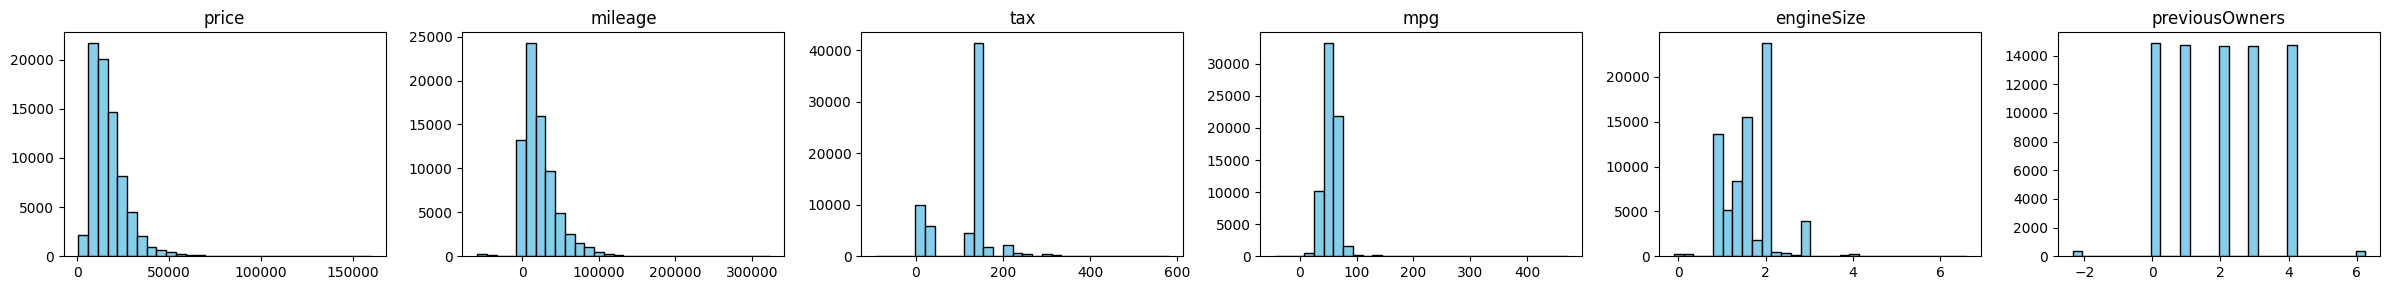

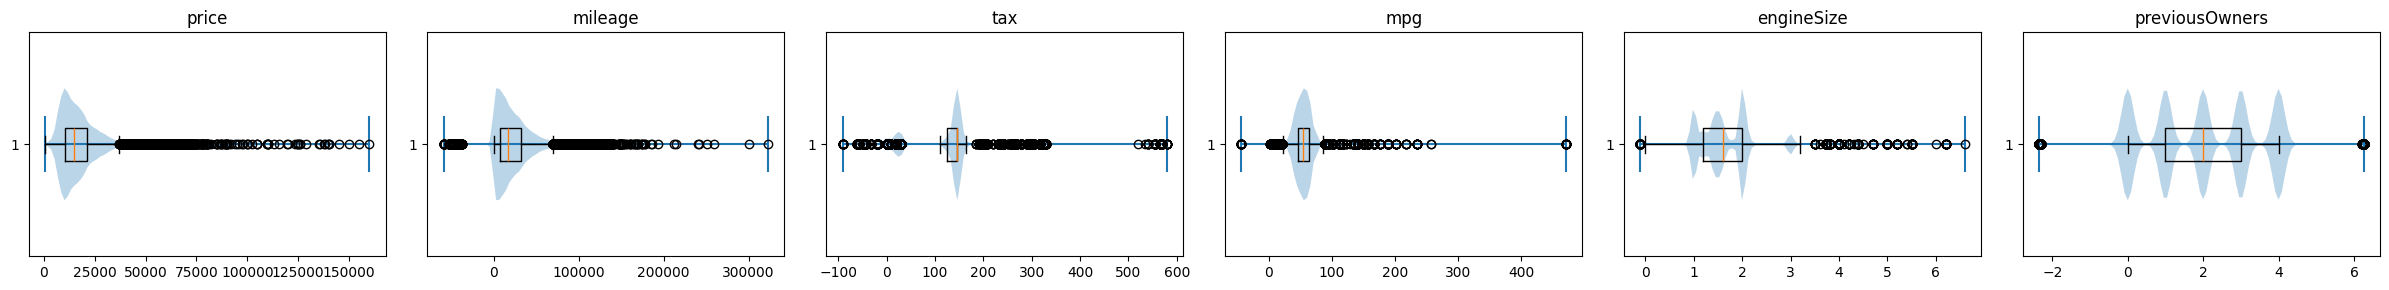

In [16]:
describe_data(
    train_df,
    [
        "price",
        "mileage",
        "tax",
        "mpg",
        "engineSize",
        "previousOwners",
    ],
    ["Brand", "model", "year", "transmission", "fuelType", "hasDamage"],
)

Our training dataset contains:

- No duplicate values
- Missing values in all columns except `carID` (the index) and `price` (the
  target variable)
- Outliers
- Some data types or values that do not make sense such as:
  - Floats in the `year`, `mileage`, `tax`, `paintQuality%`, `previousOwners`
    and `hasDamage` columns. These should be integers.
  - Negative values in `mileage`, `tax`, `mpg` (miles per galon), `engineSize`
    and `previousOwners`, these should always be positive.
  - Unrealistic values such as `engineSize` or `mpg` being 0.


In [17]:
x_train: pl.DataFrame = train_df.drop("price", "paintQuality%")
y_train: pl.DataFrame = train_df.select("price")

## Preprocessing


### Inconsistencies and Outliers


As mentioned before, our dataset contains outliers and inconsistencies. To
tackle the unrealistic values we decided to bind the data to values that made
sense.

The values that we decided on are as follows:

- `Mileage`:
  - Minimum: 1, since Cars 4 You is a resale company, the cars have to be used.
  - Maximum: None, there should be no upper limit to the mileage in a car, if
    anything, this should affect the quality of the car and, consequently, its
    price.
- `Tax`:
  - Minimum: 0, tax exemptions
  - Maximum: 400, values of tax above 360-370 are outliers, the next value found
    is above 500, 400 was chosen due to it being a nice, round number. Even
    though the outliers don't seem to be unrealistic, we were worried that
    leaving them in would negatively impact the performance of our model, as
    such, this upper breakpoint is subject to change.
- `Miles per Gallon`:
  - Minimum: 20, after doing some research, this seemed like a reasonable
    minimum.
  - Maximum: 200, same reasoning as above.
- `Engine Size`:
  - Minimum: 1.0, same reasoning as miles per gallon
  - Maximum: 6.0, same reasoning as miles per gallon
- `Paint Quality %`:
  - Minimum: 0, it's a percentage value, there should not be values under 0
  - Maximum: 100, same reasoning as above, there should not be values above 100
- `Previous Owners`:
  - Minimum: 0, a car cannot have a negative amount of previous owners
  - Maximum: None, considered a maximum of 4, due to there being outliers above
    this value. However, it's not a nonsensical value, so we left it for now,
    just like tax, this is subject to change.
- `Year`:
  - Minimum: 0.
  - Maximum: 2020, the data is from 2020, as such, year cannot be higher than
    2020, we don't think Cars 4 You is in possession of a time machine.


### Missing Values


#### Metric Features


Filling with the median of the respective feature.


#### Boolean Features


Filling with 0. The only boolean feature present in the dataset is the
`hasDamage` feature. We can assume that if a car was checked by a mechanic, and
was damaged, it would not have been forgotten. As such filling with 0 did not
seem unreasonable. Even without this assumption, every non-missing value is 0,
and, with only 2.04% of missing values, we can safely assume that these missing
values are much more likely to be 0 than 1.


#### Categorical Features


We're merging the null and the unknown columns after dummies are created, e.g.
`brand_null` and `brand_unknown` get merged. If the null dummy column exists for
a categorical feature but the unknown dummy column doesn't, the former gets
renamed to `feature_name_unknown` where `feature_name` is the name of the
categorical feature. This would be equivalent to filling with "`unknown`".


##### Issues in Categorical Features


The columns for the brand, model, transmission and fuel type of the car present
spelling mistakes. Fixing brand, transmission and fuel type is easy, as the
correct values are easy to discover. We just have to compare each of the values
in these columns to the correct values and replace by the appropriate, corrected
value.

The model column however, was harder to fix. There is a lot of overlap between
models of different brands, for example the i3 from BMW and the I30 from
Hyundai, if we are presented with a model i3, should we leave it as i3, or
should we replace it by i30? Just getting the list of corrected models was not
enough, we had to look for a list of models for each of the brands present in
the dataset. After acquiring this list, we fixed the values by comparing the
current value to the ones in the list, taking into account the brand of the
entry (if it is not missing), this way, a i3 entry with brand BMW will remain as
i3 whilst a i3 entry with brand Hyundai will be replaced by i30.

There's also the situation on which we want to fix a model, but don't have the
brand of an entry, in this case, we first got the brand of the entry by
comparing its model to the aforementioned list of models, getting the brand that
the model belongs to, then running the function to fix models once more.


Thus, the process is as follows:

- Run `fix models` to fix all models possible
- Run `fix models with no brand`
- Run `fix models` again to fix more models, now that brands is filled


For this process to run as smoothly as possible, some assumptions had to be
made, they are as follows:

1. If brand is missing, models `i3` and `i8` belong to BMW. This was concluded
   by manually looking into the dataset, and comparing the remaining features.
1. No more than 2 characters were removed in models. This avoids some cases of
   multiple matches, for example, if there was an entry `cl`, it will be
   replaced by `clk` and not `cl class`, `cla class` or `clc class` due to these
   being much longer than the entry present in the dataset.
1. For models that have exactly 2 matches we decided to maintain the value
   present in the dataset instead of trying to replace it. This would lead to an
   entry having multiple matches, which could only be resolvable by comparing
   the remaining features of the entry to those of the possible matches. We
   decided against this approach, simply because keeping the original entry was
   easier. An example of this are the models `ka` and `ka+` and `mokka` and
   `mokka x`.
1. Model entries `a` and `q` belong to Audi. Model entries `x` belong to BMW.
   Any model that starts with these letters besides the ones that belong to the
   aforementioned brands have a character difference larger than 2, as such,
   they're invalidated by assumption 2.
1. Model entries `k` are considered `ka` and not `ka+`. The features of these
   models are extremely similar, therefore, whether we assign `k` to `ka` or
   `ka+` shouldn't really matter.


### Dummy Variables


We are making n dummies for each categorical feature instead of n-1, n being the
number of different values existent in that feature. This is done to ensure that
all values of the categorical feature in the training set appear in the test
set. We are aware this introduces multicollinearity.


### Data Scaling


We decided to go with normalization.

As we're using polars, we wanted to make use of our own methods as much as
possible to avoid excessive conversion to pandas dataframes/series or numpy
arrays. Normalization was the one that came up to discussion first and as such
we decided to implement it.


In [18]:
preproc_pipeline: Pipeline = build_preprocessing_pipeline(
    metric_features=[
        "mileage",
        "tax",
        "mpg",
        "engineSize",
        "previousOwners",
    ],
    bool_features=[
        "hasDamage",
    ],
    categorical_features=[
        "Brand",
        "model",
        "year",
        "transmission",
        "fuelType",
    ],
    thresholds={
        "mileage": {"lower": 1, "upper": None},
        "tax": {"lower": 0, "upper": 400},
        "mpg": {"lower": 20, "upper": 200},
        "engineSize": {"lower": 1.0, "upper": 6.0},
        "previousOwners": {"lower": 0, "upper": None},
        "year": {"lower": 0, "upper": 2020},
    },
    winsorize=False,
    unneeded_float_features=[
        "year",
        "mileage",
        "tax",
        "previousOwners",
        "hasDamage",
    ],
    scaling_exclude_selector=("_", "hasDamage", "carID"),
    columns_to_coalesce=(
        "Brand",
        "model",
        "transmission",
        "fuelType",
        "year",
    ),
)

## Feature Selection


Our feature selection goes as follows:

- Removing `paintQuality%` as it is a feature whose values are given by the
  mechanic. Since we want to create a model capable of evaluating the price of a
  car based on the user’s input without needing the car to be taken to a
  mechanic, this feature is irrelevant.
- Remove features that are constant.
- Remove features with high correlation (>0.8).
- Select the most important features based on their contribution to a Random
  Forest Regressor's prediction accuracy.


In [19]:
fs_pipeline: Pipeline = build_feature_selection_pipeline(
    corr_threshold=0.8,
    estimator=RandomForestRegressor(
        max_depth=10,
        n_estimators=300,
        max_features="sqrt",
        n_jobs=-1,
        random_state=42,
    ),
    importance_threshold=1e-6,
)

## Model


We decided to choose the following estimators:

- [Linear Regression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html).
- [Random Forest](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html)
- [Decision Tree](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html)
- [KNN](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsRegressor.html)
- [Elastic Net](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html)


### Model Selection/Tuning


We are performing 5 fold cross validation for all models. At the same time we
are tuning the hyperparameters for each model (except Linear Regression) using
Optuna.


In [20]:
lr_pipeline = Pipeline(
    steps=[
        ("preprocessing", preproc_pipeline),
        ("feature_selection", fs_pipeline),
        ("regressor", LinearRegression()),
    ]
)

cross_val_lr = cross_validate(
    lr_pipeline,
    cast("DataFrame", x_train),
    cast("Series", y_train),
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
    ),
    n_jobs=-1,
)

lr_pipeline.fit(cast("DataFrame", x_train), cast("Series", y_train))

lr_predictions: NDArray[Any] = cast(
    "NDArray[Any]", lr_pipeline.predict(cast("DataFrame", test_df))
).flatten()

pl.DataFrame(
    {"carID": test_df.get_column("carID"), "price": lr_predictions}
).write_csv("data/submission-lr.csv")

In [21]:
# rf_pipeline = Pipeline(
#     steps=[
#         ("preprocessing", preproc_pipeline),
#         ("feature_selection", fs_pipeline),
#         (
#             "regressor",
#             RandomForestRegressor(
#                 criterion="squared_error", random_state=42, n_jobs=-1
#             ),
#         ),
#     ]
# )

# optuna_search_rf = OptunaSearchCV(
#     rf_pipeline,
#     {
#         "regressor__n_estimators": optuna.distributions.IntDistribution(
#             100, 800
#         ),
#         "regressor__max_depth": optuna.distributions.IntDistribution(2, 18),
#         "regressor__min_samples_split": optuna.distributions.IntDistribution(
#             2, 200
#         ),
#         "regressor__min_samples_leaf": optuna.distributions.IntDistribution(
#             1, 100
#         ),
#         "regressor__max_features": optuna.distributions.FloatDistribution(
#             0.0, 1.0
#         ),
#         "regressor__max_leaf_nodes": optuna.distributions.IntDistribution(
#             50, 200
#         ),
#         "regressor__min_impurity_decrease": optuna.distributions.FloatDistribution(
#             0.0, 0.001
#         ),
#     },
#     cv=5,
#     n_jobs=-1,
#     n_trials=300,
#     random_state=42,
#     refit=True,
#     scoring="neg_root_mean_squared_error",
# )

# optuna_search_rf.fit(cast("DataFrame", x_train), cast("Series", y_train))

# rf_predictions: NDArray[Any] = cast(
#     "NDArray[Any]", optuna_search_rf.predict(cast("DataFrame", test_df))
# ).flatten()

# pl.DataFrame(
#     {"carID": test_df.get_column("carID"), "price": rf_predictions}
# ).write_csv("data/submission-rf.csv")

In [22]:
# dt_pipeline = Pipeline(
#     steps=[
#         ("preprocessing", preproc_pipeline),
#         ("feature_selection", fs_pipeline),
#         ("regressor", DecisionTreeRegressor(random_state=42)),
#     ]
# )

# optuna_search_dt = OptunaSearchCV(
#     dt_pipeline,
#     {
#         "regressor__max_depth": optuna.distributions.IntDistribution(2, 18),
#         "regressor__min_samples_split": optuna.distributions.IntDistribution(
#             2, 200
#         ),
#         "regressor__min_samples_leaf": optuna.distributions.IntDistribution(
#             1, 100
#         ),
#         "regressor__max_leaf_nodes": optuna.distributions.IntDistribution(
#             50, 200
#         ),
#         "regressor__min_impurity_decrease": optuna.distributions.FloatDistribution(
#             0.0, 0.001
#         ),
#     },
#     cv=5,
#     n_jobs=-1,
#     n_trials=300,
#     random_state=42,
#     refit=True,
#     scoring="neg_root_mean_squared_error",
# )

# optuna_search_dt.fit(cast("DataFrame", x_train), cast("Series", y_train))

# dt_predictions: NDArray[Any] = cast(
#     "NDArray[Any]", optuna_search_dt.predict(cast("DataFrame", test_df))
# ).flatten()

# pl.DataFrame(
#     {"carID": test_df.get_column("carID"), "price": dt_predictions}
# ).write_csv("data/submission-dt.csv")

In [23]:
# knn_pipeline = Pipeline(
#     steps=[
#         ("preprocessing", preproc_pipeline),
#         ("feature_selection", fs_pipeline),
#         ("regressor", KNeighborsRegressor(n_jobs=-1)),
#     ]
# )

# optuna_search_knn = OptunaSearchCV(
#     knn_pipeline,
#     {
#         "regressor__n_neighbors": optuna.distributions.IntDistribution(10, 50),
#         "regressor__weights": optuna.distributions.CategoricalDistribution(
#             ["uniform", "distance"]
#         ),
#         "regressor__algorithm": optuna.distributions.CategoricalDistribution(
#             ["ball_tree", "kd_tree"]
#         ),
#         "regressor__p": optuna.distributions.IntDistribution(1, 2),
#     },
#     cv=5,
#     n_jobs=-1,
#     n_trials=150,
#     random_state=42,
#     refit=True,
#     scoring="neg_root_mean_squared_error",
# )

# optuna_search_knn.fit(cast("DataFrame", x_train), cast("Series", y_train))

# knn_predictions: NDArray[Any] = cast(
#     "NDArray[Any]", optuna_search_knn.predict(cast("DataFrame", test_df))
# ).flatten()

# pl.DataFrame(
#     {"carID": test_df.get_column("carID"), "price": knn_predictions}
# ).write_csv("data/submission-knn.csv")

In [24]:
# en_pipeline = Pipeline(
#     steps=[
#         ("preprocessing", preproc_pipeline),
#         ("feature_selection", fs_pipeline),
#         (
#             "regressor",
#             ElasticNet(random_state=42),
#         ),
#     ]
# )

# optuna_search_en = OptunaSearchCV(
#     en_pipeline,
#     {
#         "regressor__alpha": optuna.distributions.FloatDistribution(0.01, 10),
#         "regressor__l1_ratio": optuna.distributions.FloatDistribution(0, 1),
#         "regressor__tol": optuna.distributions.FloatDistribution(1e-4, 0.1),
#         "regressor__selection": optuna.distributions.CategoricalDistribution(
#             ["cyclic", "random"]
#         ),
#     },
#     cv=5,
#     n_jobs=-1,
#     n_trials=300,
#     random_state=42,
#     refit=True,
#     scoring="neg_root_mean_squared_error",
# )

# optuna_search_en.fit(cast("DataFrame", x_train), cast("Series", y_train))

# en_predictions: NDArray[Any] = cast(
#     "NDArray[Any]", optuna_search_en.predict(cast("DataFrame", test_df))
# ).flatten()

# pl.DataFrame(
#     {"carID": test_df.get_column("carID"), "price": en_predictions}
# ).write_csv("data/submission-en.csv")

### Getting each model's hyperparameters


In [25]:
# optuna_search_rf.best_estimator_.steps[2][1].get_params()

In [26]:
# optuna_search_dt.best_estimator_.steps[2][1].get_params()

In [27]:
# optuna_search_knn.best_estimator_.steps[2][1].get_params()

In [28]:
# optuna_search_en.best_estimator_.steps[2][1].get_params()

Instead of getting the best estimator directly from the optuna search variables,
we use a new instance of the estimators with the hyperparameters given by the
respective optuna searches. This is done to avoid having to spend 11 hours 53
minutes and 21 seconds staring at the ceiling while optuna searches for the best
hyperparameters.


In [29]:
cross_val_rf = cross_validate(
    Pipeline(
        steps=[
            ("preprocessing", preproc_pipeline),
            ("feature_selection", fs_pipeline),
            (
                "regressor",
                RandomForestRegressor(
                    max_depth=18,
                    max_features=0.8512243795321489,
                    max_leaf_nodes=200,
                    min_impurity_decrease=0.0009513328212059685,
                    min_samples_leaf=1,
                    min_samples_split=50,
                    n_estimators=661,
                    n_jobs=-1,
                    random_state=42,
                ),
            ),
        ]
    ),
    cast("DataFrame", x_train),
    cast("Series", y_train),
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
    ),
    n_jobs=-1,
)

cross_val_dt = cross_validate(
    Pipeline(
        steps=[
            ("preprocessing", preproc_pipeline),
            ("feature_selection", fs_pipeline),
            (
                "regressor",
                DecisionTreeRegressor(
                    max_depth=12,
                    max_leaf_nodes=200,
                    min_impurity_decrease=0.0009299085609204971,
                    min_samples_leaf=1,
                    min_samples_split=17,
                    random_state=42,
                ),
            ),
        ]
    ),
    cast("DataFrame", x_train),
    cast("Series", y_train),
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
    ),
    n_jobs=-1,
)

cross_val_knn = cross_validate(
    Pipeline(
        steps=[
            ("preprocessing", preproc_pipeline),
            ("feature_selection", fs_pipeline),
            (
                "regressor",
                KNeighborsRegressor(
                    algorithm="kd_tree",
                    metric="minkowski",
                    n_jobs=-1,
                    n_neighbors=10,
                    p=1,
                    weights="distance",
                ),
            ),
        ]
    ),
    cast("DataFrame", x_train),
    cast("Series", y_train),
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
    ),
    n_jobs=-1,
)

cross_val_en = cross_validate(
    Pipeline(
        steps=[
            ("preprocessing", preproc_pipeline),
            ("feature_selection", fs_pipeline),
            (
                "regressor",
                ElasticNet(
                    alpha=0.037092408647509345,
                    l1_ratio=0.9998680118747498,
                    random_state=42,
                    selection="random",
                    tol=0.011935571775345535,
                ),
            ),
        ]
    ),
    cast("DataFrame", x_train),
    cast("Series", y_train),
    cv=5,
    scoring=(
        "r2",
        "neg_mean_absolute_error",
        "neg_mean_squared_error",
        "neg_root_mean_squared_error",
    ),
    n_jobs=-1,
)

In [30]:
scores = pl.DataFrame(
    {
        "estimator": (
            "LinearRegression",
            "RandomForest",
            "DecisionTree",
            "KNeighbors",
            "ElasticNet",
        ),
        "R2": (
            cross_val_lr["test_r2"].mean(),
            cross_val_rf["test_r2"].mean(),
            cross_val_dt["test_r2"].mean(),
            cross_val_knn["test_r2"].mean(),
            cross_val_en["test_r2"].mean(),
        ),
        "MAE": (
            -cross_val_lr["test_neg_mean_absolute_error"].mean(),
            -cross_val_rf["test_neg_mean_absolute_error"].mean(),
            -cross_val_dt["test_neg_mean_absolute_error"].mean(),
            -cross_val_knn["test_neg_mean_absolute_error"].mean(),
            -cross_val_en["test_neg_mean_absolute_error"].mean(),
        ),
        "MSE": (
            -cross_val_lr["test_neg_mean_squared_error"].mean(),
            -cross_val_rf["test_neg_mean_squared_error"].mean(),
            -cross_val_dt["test_neg_mean_squared_error"].mean(),
            -cross_val_knn["test_neg_mean_squared_error"].mean(),
            -cross_val_en["test_neg_mean_squared_error"].mean(),
        ),
        "RMSE": (
            -cross_val_lr["test_neg_root_mean_squared_error"].mean(),
            -cross_val_rf["test_neg_root_mean_squared_error"].mean(),
            -cross_val_dt["test_neg_root_mean_squared_error"].mean(),
            -cross_val_knn["test_neg_root_mean_squared_error"].mean(),
            -cross_val_en["test_neg_root_mean_squared_error"].mean(),
        ),
    }
)
scores

estimator,R2,MAE,MSE,RMSE
str,f64,f64,f64,f64
"""LinearRegression""",0.856375,2308.26753,1.3606e7,3686.445032
"""RandomForest""",0.887301,2194.128201,1.0679e7,3266.316598
"""DecisionTree""",0.85334,2502.830829,1.3899e7,3725.52932
"""KNeighbors""",0.325504,5421.575419,6.3942e7,7996.12949
"""ElasticNet""",0.856445,2309.044039,1.3600e7,3685.577166


Our best model is Random Forest, it has the highest R² whilst also having the
lowest value in all error metrics. A thing to note is KNN had the worst scores,
this is likely due to feature selection, doing a feature selection more focused
towards it would greatly improve its score.


### Feature Selection for our best model


During hyperparameter tuning, the pipelines used a tree based feature selection
as that would be faster than running feature permutation based one. Now that we
have our best model, we can improve on the feature selection we did before to
try to achieve better performance. To do this we are going to use the
aforementioned feature permutation based feature selection.


In [31]:
permutation_fs_pipeline: Pipeline = (
    build_permutation_feature_selection_pipeline(
        corr_threshold=0.8,
        estimator=RandomForestRegressor(
            max_depth=18,
            max_features=0.8512243795321489,
            max_leaf_nodes=200,
            min_impurity_decrease=0.0009513328212059685,
            min_samples_leaf=1,
            min_samples_split=50,
            n_estimators=661,
            n_jobs=-1,
            random_state=42,
        ),
        n_repeats=10,
        scoring="neg_root_mean_squared_error",
        importance_threshold=1e-5,
    )
)

final_pipeline = Pipeline(
    steps=[
        ("preprocessing", preproc_pipeline),
        ("feature_selection", permutation_fs_pipeline),
        (
            "regressor",
            RandomForestRegressor(
                max_depth=18,
                max_features=0.8512243795321489,
                max_leaf_nodes=200,
                min_impurity_decrease=0.0009513328212059685,
                min_samples_leaf=1,
                min_samples_split=50,
                n_estimators=661,
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

In [32]:
# final_pipeline_scores = cross_validate(
#     final_pipeline,
#     cast("DataFrame", x_train),
#     cast("Series", y_train),
#     cv=5,
#     scoring=(
#         "r2",
#         "neg_mean_absolute_error",
#         "neg_mean_squared_error",
#         "neg_root_mean_squared_error",
#     ),
#     n_jobs=-1,
# )

# pl.DataFrame(
#     {
#         "Metric": ["R2", "MAE", "MSE", "RMSE"],
#         "Final Pipeline": [
#             final_pipeline_scores["test_r2"].mean(),
#             -final_pipeline_scores["test_neg_mean_absolute_error"].mean(),
#             -final_pipeline_scores["test_neg_mean_squared_error"].mean(),
#             -final_pipeline_scores["test_neg_root_mean_squared_error"].mean(),
#         ],
#     }
# )

As we can see, the scores improved, R² is higher while mae, mse and rmse are
lower. However this improvement is minimal, which suggests that, our previous
feature selection was already good enough. This could also be due to our chosen
importance threshold, changing it might change which features get selected and
thus further improving (or worsening) the performance of our model.


In [33]:
# final_pipeline.fit(cast("DataFrame", x_train), cast("Series", y_train))

In [34]:
# get_features_pipeline: Pipeline = Pipeline(
#     steps=[
#         ("preprocessing", preproc_pipeline),
#         ("feature_selection", permutation_fs_pipeline),
#     ]
# )

# get_features_pipeline.fit(cast("DataFrame", x_train), cast("Series", y_train))

# selected_features: pl.DataFrame = pl.DataFrame(
#     get_features_pipeline.transform(cast("DataFrame", x_train))
# )
# selected_features.columns

## Final Model


To avoid having to wait 13 minutes to fit the final pipeline, below is provided
a pipeline that uses the features chosen by the feature permutation based
feature selection and the hyperparameters found through the Optuna search.


In [35]:
final_pipeline_no_run = Pipeline(
    steps=[
        ("preprocessing", preproc_pipeline),
        (
            "feature_selection",
            FunctionTransformer(
                lambda x: x.select(
                    [
                        "Brand_audi",
                        "Brand_bmw",
                        "Brand_ford",
                        "Brand_hyundai",
                        "Brand_mercedes",
                        "Brand_unknown",
                        "Brand_opel",
                        "Brand_skoda",
                        "Brand_toyota",
                        "Brand_vw",
                        "carID",
                        "engineSize",
                        "fuelType_diesel",
                        "fuelType_hybrid",
                        "fuelType_unknown",
                        "fuelType_other",
                        "mileage",
                        "model_1 series",
                        "model_2 series",
                        "model_3 series",
                        "model_4 series",
                        "model_5 series",
                        "model_6 series",
                        "model_7 series",
                        "model_8 series",
                        "model_a class",
                        "model_a1",
                        "model_a3",
                        "model_a4",
                        "model_a5",
                        "model_a6",
                        "model_a7",
                        "model_a8",
                        "model_adam",
                        "model_amarok",
                        "model_arteon",
                        "model_astra",
                        "model_auris",
                        "model_aygo",
                        "model_b class",
                        "model_beetle",
                        "model_c class",
                        "model_c-hr",
                        "model_california",
                        "model_caravelle",
                        "model_cl class",
                        "model_cla class",
                        "model_cls class",
                        "model_corsa",
                        "model_e class",
                        "model_edge",
                        "model_fabia",
                        "model_fiesta",
                        "model_focus",
                        "model_g class",
                        "model_gla class",
                        "model_glc class",
                        "model_gle class",
                        "model_gls class",
                        "model_golf",
                        "model_grandland x",
                        "model_gt86",
                        "model_i10",
                        "model_i20",
                        "model_i8",
                        "model_i800",
                        "model_insignia",
                        "model_ix20",
                        "model_ka+",
                        "model_kamiq",
                        "model_karoq",
                        "model_kodiaq",
                        "model_kuga",
                        "model_land cruiser",
                        "model_m class",
                        "model_m3",
                        "model_m4",
                        "model_m5",
                        "model_mokka x",
                        "model_mondeo",
                        "model_mustang",
                        "model_octavia",
                        "model_passat",
                        "model_polo",
                        "model_prius",
                        "model_puma",
                        "model_q3",
                        "model_q5",
                        "model_q7",
                        "model_q8",
                        "model_r8",
                        "model_rav4",
                        "model_rs3",
                        "model_rs4",
                        "model_rs5",
                        "model_rs6",
                        "model_s class",
                        "model_s4",
                        "model_s8",
                        "model_santa fe",
                        "model_sharan",
                        "model_shuttle",
                        "model_sl class",
                        "model_slk",
                        "model_sq7",
                        "model_superb",
                        "model_supra",
                        "model_t-cross",
                        "model_t-roc",
                        "model_tiguan",
                        "model_tourneo custom",
                        "model_tt",
                        "model_tucson",
                        "model_unknown",
                        "model_up",
                        "model_v class",
                        "model_viva",
                        "model_x-class",
                        "model_x1",
                        "model_x3",
                        "model_x4",
                        "model_x5",
                        "model_x6",
                        "model_x7",
                        "model_yaris",
                        "model_z4",
                        "mpg",
                        "previousOwners",
                        "tax",
                        "transmission_automatic",
                        "transmission_manual",
                        "transmission_semi-auto",
                        "transmission_unknown",
                        "year_1998",
                        "year_1999",
                        "year_2001",
                        "year_2002",
                        "year_2003",
                        "year_2004",
                        "year_2005",
                        "year_2006",
                        "year_2007",
                        "year_2008",
                        "year_2009",
                        "year_2010",
                        "year_2011",
                        "year_2012",
                        "year_2013",
                        "year_2014",
                        "year_2015",
                        "year_2016",
                        "year_2017",
                        "year_2018",
                        "year_2019",
                        "year_2020",
                        "year_unknown",
                    ]
                )
            ),
        ),
        ("to_pandas", FunctionTransformer(lambda x: x.to_pandas())),
        (
            "regressor",
            RandomForestRegressor(
                max_depth=18,
                max_features=0.8512243795321489,
                max_leaf_nodes=200,
                min_impurity_decrease=0.0009513328212059685,
                min_samples_leaf=1,
                min_samples_split=50,
                n_estimators=661,
                n_jobs=-1,
                random_state=42,
            ),
        ),
    ]
)

final_pipeline_no_run.fit(cast("DataFrame", x_train), cast("Series", y_train))

final_predictions: NDArray[Any] = cast(
    "NDArray[Any]", final_pipeline_no_run.predict(cast("DataFrame", test_df))
).flatten()

pl.DataFrame(
    {"carID": test_df.get_column("carID"), "price": final_predictions}
).write_csv("data/submission-final.csv")

## Predicting car prices for new data


See the readme for instructions on how to run the interface.


## Ablation Study


In [36]:
# performance: dict[str, list[str | float]] = {
#     "steps": [],
#     "r2": [],
#     "mae": [],
#     "mse": [],
#     "rmse": [],
# }


# def _append_scores(ablation_pipeline: Pipeline) -> None:
#     try:
#         ablation_cv_results = cross_validate(
#             ablation_pipeline,
#             cast("DataFrame", x_train),
#             cast("Series", y_train),
#             cv=5,
#             scoring=(
#                 "r2",
#                 "neg_mean_absolute_error",
#                 "neg_mean_squared_error",
#                 "neg_root_mean_squared_error",
#             ),
#             n_jobs=-1,
#         )
#         performance["r2"].append(
#             ablation_cv_results["test_r2"].mean()
#             - final_pipeline_scores["test_r2"].mean()
#         )
#         performance["mae"].append(
#             -ablation_cv_results["test_neg_mean_absolute_error"].mean()
#             + final_pipeline_scores["test_neg_mean_absolute_error"].mean()
#         )
#         performance["mse"].append(
#             -ablation_cv_results["test_neg_mean_squared_error"].mean()
#             + final_pipeline_scores["test_neg_mean_squared_error"].mean()
#         )
#         performance["rmse"].append(
#             -ablation_cv_results["test_neg_root_mean_squared_error"].mean()
#             + final_pipeline_scores["test_neg_root_mean_squared_error"].mean()
#         )
#     except Exception:
#         performance["r2"].append(-np.inf)
#         performance["mae"].append(-np.inf)
#         performance["mse"].append(-np.inf)
#         performance["rmse"].append(-np.inf)


# for step_index, step in enumerate(final_pipeline.steps[0][1].named_steps):
#     ablation_pp: Pipeline = clone(final_pipeline)
#     ablation_pp.steps[0][1].steps.pop(step_index)
#     performance["steps"].append(step)
#     _append_scores(ablation_pp)


# for step_index, step in enumerate(final_pipeline.steps[1][1].named_steps):
#     ablation_pp: Pipeline = clone(final_pipeline)
#     ablation_pp.steps[1][1].steps.pop(step_index)
#     performance["steps"].append(step)
#     _append_scores(ablation_pp)

# ablation_performance_df: pl.DataFrame = pl.DataFrame(performance)
# ablation_performance_df

The interpretation of the values above is as follows:

Negative values on the R² mean worse performance, positive values on mae, mse
and rmse mean worse performance. The only exception to this are the -inf rows,
which mean the pipeline couldn't run without that step.

The ablation study shows that all of the steps, with the exception of
fix_brands, have a similar impact on performance. Whether negative or positive,
the individual impact of each step on performance is minimal. fix_brands is the
most important step, removing it worsens the performance of our model more than
the other steps.

It's important to note that this shows only the individual impact of each step,
the interaction effects between steps is not shown by these results. Removing
more than one step could drastically reduce the performance of our model.
Finding the best combination of steps for the pipeline is another task in itself
that would take an absurd amount of time. Testing the best combination of all
steps would take 2^13 - 1 times the time it took for this ablation study to run.
That's about 2546 days.
